# 1. Setting up Notebook Environment

In [73]:
# auto-reload external scripts
%load_ext autoreload
%autoreload 2

# imports

import pandas as pd
import sys, os 
from IPython.display import display, HTML
from IPython.display import Image, Markdown
import json
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Setting Up Nomic Atlas's Character.AI Dataset

In [74]:
# -----------------------------
# Notebook setup for Nomic CAI Dataset
# -----------------------------

# add project root to Python path
sys.path.append(os.path.abspath(".."))

# import login function
from scripts.nomic_login import login_nomic

# log in to Nomic Atlas
login_nomic()

# import cai.dataset loading function
from scripts.cai_nomic import load_nomic_dataset

# try loading the dataset
try:
    df, meta = load_nomic_dataset()
    print(f"Dataset loaded successfully!")
except Exception as e:
    df = None
    print("Failed to load dataset:", e)

Login Successful!


2026-04-10 17:10:04.813 | INFO     | nomic.dataset:__init__:817 - Loading existing dataset `auth0thread765/all-cai-characters-`.
2026-04-10 17:10:06.060 | WARNING  | nomic.data_operations:df:1173 - Converting to pandas dataframe. This may materialize a large amount of data into memory.
2026-04-10 17:10:06.062 | INFO     | nomic.data_operations:_download_data:1142 - Downloading data
100%|████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 3655.98it/s]
2026-04-10 17:10:06.895 | INFO     | nomic.data_operations:_load_data:1069 - Loading data
100%|██████████████████████████████████████████████████████████████████████████████████| 37/37 [00:02<00:00, 17.76it/s]


Dataset loaded successfully!


# 3. General Overview of Character.ai Dataset on Nomic

## 3.1 Metadata

In [45]:
#print(meta)

In [69]:
display(HTML(f"""<h3>3.1 Metadata Summary</h3><br>"""))

#printing important metadata 
def metadata_summary(meta):
    print("DATASET INFORMATION")
    print(f"Project Name: {meta.get('project_name')}")
    print(f"Project ID: {meta.get('id')}")
    print(f"Creator / Owner Nickname: {meta.get('creator_nickname')}")
    print(f"Creator ID: {meta.get('creator')}")
    print(f"Organization: {meta.get('organization_name')}")
    print(f"Is Public: {meta.get('is_public')}")
    print(f"Privacy Level: {meta.get('privacy')}")
    print(f"Created Timestamp: {meta.get('created_timestamp')}")
    print(f"Total Data Points: {meta.get('total_datums_in_project'):,}")
    print()
    print("METADATA FIELDS")
    print("Project Fields:", ", ".join(meta.get('project_fields', [])))
    print(f"Unique ID Field: {meta.get('unique_id_field')}")
    print(f"Modality: {meta.get('modality')}")
    print()
    print("ACCESS / PERMISSIONS")
    print(f"Access Role: {meta.get('access_role')}")
    permissions = meta.get('permissions', {})
    print(f"Can Read Metadata: {permissions.get('dataset:metadata:read')}")
    print(f"Can Read Data: {permissions.get('dataset:data:read')}")
    print(f"Can Write / Edit Data: {permissions.get('dataset:data:write')}")
    print()
    print("NOMIC ATLAS EMBEDDINGS")
    for idx in meta.get('atlas_indices', []):
        print(f"Atlas Index Name: {idx.get('index_name')}")
        print(f"Indexed Field: {idx.get('indexed_field')}")
        print(f"Atoms: {', '.join(idx.get('atoms', []))}")
        print(f"Colorable Fields: {', '.join(idx.get('colorable_fields', []))}")
        for embed in idx.get('embedders', []):
            print(f"Embeddings Model: {embed.get('model_name')} (ready: {embed.get('ready')})")
    print()
    print("OTHER INFO")
    print(f"Slug: {meta.get('slug')}")
    print(f"Connector: {meta.get('connector_name')}")
    for m in meta.get('maps', []):
        print(f"Maps Data Points: {m.get('total_data_points')}")
    analyst_info = meta.get('analyst_info', {})
    print(f"Analyst Info: AI Subprocessor = {analyst_info.get('ai_subprocessor')}")


metadata_summary(meta)

DATASET INFORMATION
Project Name: All C.AI Characters 
Project ID: 153aa02c-6b4b-4723-858c-c3c8622d31fc
Creator / Owner Nickname: auth0.thread765
Creator ID: auth0|672181d2ac71294fbcfdb387
Organization: auth0.thread765
Is Public: True
Privacy Level: public
Created Timestamp: 2024-10-31T00:08:09.155322Z
Total Data Points: 783,978

METADATA FIELDS
Project Fields: avatar, name, description, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id, row_number
Unique ID Field: row_number
Modality: text

ACCESS / PERMISSIONS
Access Role: EXTERNAL
Can Read Metadata: True
Can Read Data: True
Can Write / Edit Data: False

NOMIC ATLAS EMBEDDINGS
Atlas Index Name: All C.AI Characters 
Indexed Field: description
Atoms: charchunk, document
Colorable Fields: avatar, name, expertise, personality_question, personality_answer, greeting, upvotes, interactions, categories, creator, language, participant, external_id
Embe

## 3.2 Database Size and Structure

In [70]:
#Dataset Size and Structure

cols_df = df.dtypes.reset_index()           # convert series to df
cols_df.columns = ['Column', 'Data Type']  # column header

cols_html = cols_df.to_html(index=False, escape=False)
display(HTML(f"""<h3>3.2 Database Size and Column Structure</h3> 
<div style='display:flex; gap:30px; align-items:flex-start; margin-bottom:20px;'>

    <!-- Left card -->
    <div style='padding:20px; border-radius:12px; background:#069494; color:white; text-align:center; width:220px; box-shadow:0 4px 8px rgba(0,0,0,0.1);'>
        <div style='font-size:18px; font-weight:bold;'>Total Dataset</div>
        <div style='font-size:28px; font-weight:bold;'>{total_rows}</div>
        <div>Records</div>
        <div style='margin-top:5px; font-size:16px;'>{total_cols} Columns</div>
    </div>
    <!-- Right table -->
    <div style='flex:1; overflow-x:auto;'>
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
                min-width: 400px;
            }}
            th, td {{
                text-align: left;
                padding: 8px;
                white-space: nowrap;
            }}
            th {{
                background-color: #069494;
                color: white;
            }}
            tr:nth-child(even) {{
                background-color: #f2f2f2;
            }}
            tr:hover {{
                background-color: #d0f0f0;
            }}
        </style>
        {cols_html}
    </div>

</div>
"""))

Column,Data Type
row_number,object
personality_question,category
upvotes,int32
interactions,int32
categories,category
language,category
greeting,object
participant,object
avatar,object
description,object


## 3.3 Sample Dataset Records

In [71]:
display(HTML("<h3>3.3 Ten Sample Records Generated Randomly</h3>"))

sample_df = df.sample(10, random_state=42)

for _, row in sample_df.iterrows():

    display(HTML(
        "<div style='padding:10px; border:1px solid #ccc; border-radius:8px; margin-bottom:10px;'>"
        + "".join(
            f"<b>{html.escape(col.replace('_', ' ').title())}:</b> {html.escape(str(val))}<br>"
            for col, val in row.items()
        )
        + "</div>"
    ))

## 3.4 Percentage of Missing Values in Dataset

C:\Users\chahn\AppData\Local\Temp\ipykernel_33476\3775405641.py:9: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



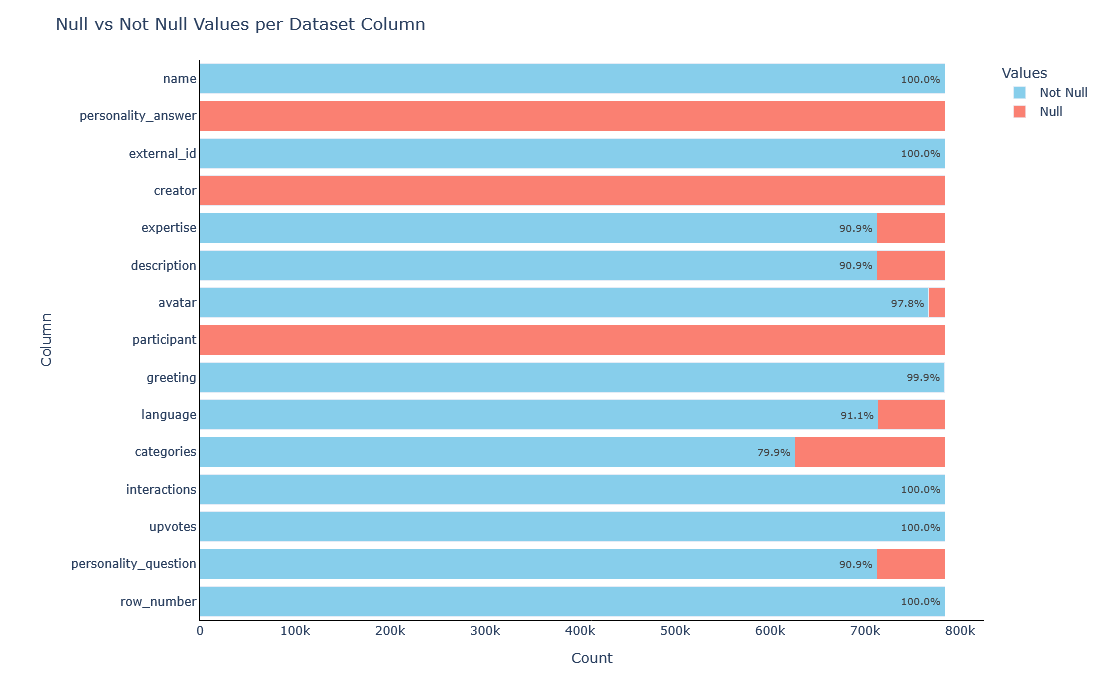

In [79]:
# 1. copy dataset for calculating missingness
df_null = df.copy()

# 2.normalize 'null' values 
object_cols = df_null.select_dtypes(include=["object", "category"]).columns
null_values = {"None", "none", "NULL", "null", "NaN", "nan", "na", "n/a", ""}

for col in object_cols:
    df_null[col] = df_null[col].replace(list(null_values), np.nan)

# in category dtype normalize null
cat_cols = df_null.select_dtypes(include=["category"]).columns

for col in cat_cols:
    df_null[col] = df_null[col].astype("object").replace("[]", np.nan)

# precompute missingness 
total = len(df_null)

df_plot = pd.DataFrame({
    "Column": df_null.columns,
    "Null": df_null.isna().sum().values,
    "Not Null": df_null.notna().sum().values
})


display(HTML("<h3>3.4 Percentage of Missing Values in Dataset (Per Column)</h3>"))

#melt for plotly 
df_melt = df_plot.melt(
    id_vars="Column",
    value_vars=["Not Null", "Null"],
    var_name="Values",
    value_name="Count"
)

# plot in plotly 
fig = px.bar(
    df_melt,
    y="Column",
    x="Count",
    color="Values",
    orientation="h",
    barmode="stack",
    color_discrete_map={
        "Not Null": "skyblue",
        "Null": "salmon"
    }
)

# show percent labels for non null in  each column
def add_percent_labels(trace):
    if trace.name == "Not Null":
        vals = df_plot["Not Null"].values
        perc = (vals / total * 100).round(1)
        trace.text = [f"{p}%" for p in perc]
    else:
        trace.text = None

fig.for_each_trace(add_percent_labels)

fig.update_traces(textposition="inside", textfont_size=10)

# display layout
fig.update_layout(
    title="Null vs Not Null Values per Dataset Column",
    height=700,
    width=1000,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=200),
    xaxis=dict(showline=True, linecolor="black"),
    yaxis=dict(showline=True, linecolor="black")
)

fig.show()

# 4. BTS Character Bots Corpus

## 4.1 Filtering BTS Bots

In [80]:

def filter_bts_bots(df, members=None):
    """
    Filter CAI dataset for BTS-related English bots.
    Args:
    df (pd.DataFrame): Full Nomic CAI dataset.
    members (list of str, optional): BTS member names to filter.

    
    Returns:
        bts_df (pd.DataFrame) df of all bts bots 
        member_counts (dict) bot counts 
    """
    #list of member names
    if members is None:
        members = ["Jungkook", "Taehyung", "Jimin", "Yoongi", "Namjoon", "Hoseok", "Seokjin"]

    pattern = "|".join(members)

    # Mask: true for bts member English-language bots that can be recognized by bot names, description or greeting 

    mask = (
        df["name"].str.contains(pattern, case=False, na=False) |
        df["description"].str.contains(pattern, case=False, na=False) |
        df["greeting"].str.contains(pattern, case=False, na=False)
    ) & (df["language"].str.lower() == "english")

    bts_df = df[mask].copy()

    #sort them by upvotes to see popular ones first
    bts_df.sort_values("upvotes", ascending=False, inplace=True)

    #count bots per member
    member_counts = {
        m: bts_df["name"].str.contains(m, case=False, na=False).sum()
        for m in members
    }

    return bts_df, member_counts

In [81]:
bts_df, counts = filter_bts_bots(df)

## 4.2 Saving Metadata CSV for Member Bots and All Members

In [90]:
import os
import pandas as pd

def save_bts_bots(bts_df, members=None, save_dir="../data/bts_bots"):
    """
    Save BTS bot subsets per member + combined dataset with 'member' column.
    All outputs are sorted by upvotes (descending).
    """

    if members is None:
        members = ["Jungkook", "Taehyung", "Jimin", "Yoongi", "Namjoon", "Hoseok", "Seokjin"]

    os.makedirs(save_dir, exist_ok=True)

    # option to overwrite
    existing_files = [
        f for f in os.listdir(save_dir)
        if f.endswith("_bots_nomic.csv")
    ]

    overwrite = False

    if existing_files:
        print("The following files already exist:")
        print(", ".join(existing_files))

        while True:
            choice = input("Do you want to overwrite them? [y/n]: ").strip().lower()

            if choice == "y":
                overwrite = True
                break
            elif choice == "n":
                overwrite = False
                break
            else:
                print("Please enter 'y' or 'n'.")

    # combined df
    all_dfs = []

    for m in members:
        member_mask = bts_df["name"].str.contains(m, case=False, na=False)
        member_df = bts_df[member_mask].copy()

        if member_df.empty:
            continue

        member_df["member"] = m
        all_dfs.append(member_df)

    total_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

    # sort by uptvotes
    if not total_df.empty:
        total_df = total_df.sort_values("upvotes", ascending=False)

    # saved combined dataset
    total_path = os.path.join(save_dir, "bts_all_members_nomic.csv")

    if os.path.exists(total_path) and not overwrite:
        print("Skipped combined dataset (already exists)")
    else:
        total_df.to_csv(total_path, index=False)
        print(f"Saved combined dataset → {total_path}")

    # save member bots
    for m in members:
        member_df = total_df[total_df["member"] == m].copy()

        if member_df.empty:
            continue

        # sort by upvotes
        member_df = member_df.sort_values("upvotes", ascending=False)

        filename = f"{m.lower()}_bots_nomic.csv"
        path = os.path.join(save_dir, filename)

        if os.path.exists(path) and not overwrite:
            print(f"Skipped {filename}")
            continue

        member_df.to_csv(path, index=False)
        print(f"Saved {len(member_df)} {m} bots → {path}")

In [91]:
save_bts_bots(bts_df)

The following files already exist:
hoseok_bots_nomic.csv, jimin_bots_nomic.csv, jungkook_bots_nomic.csv, namjoon_bots_nomic.csv, seokjin_bots_nomic.csv, taehyung_bots_nomic.csv, yoongi_bots_nomic.csv


Do you want to overwrite them? [y/n]:  y


Saved combined dataset → ../data/bts_bots\bts_all_members_nomic.csv
Saved 817 Jungkook bots → ../data/bts_bots\jungkook_bots_nomic.csv
Saved 1161 Taehyung bots → ../data/bts_bots\taehyung_bots_nomic.csv
Saved 630 Jimin bots → ../data/bts_bots\jimin_bots_nomic.csv
Saved 594 Yoongi bots → ../data/bts_bots\yoongi_bots_nomic.csv
Saved 222 Namjoon bots → ../data/bts_bots\namjoon_bots_nomic.csv
Saved 69 Hoseok bots → ../data/bts_bots\hoseok_bots_nomic.csv
Saved 84 Seokjin bots → ../data/bts_bots\seokjin_bots_nomic.csv


## 4.3 Number of BTS Bots 

In [92]:
colors = [
    "#FFADAD", "#FFD6A5", "#FDFFB6", "#CAFFBF",
    "#9BF6FF", "#A0C4FF", "#BDB2FF"
]
display(HTML(f"""<h3>4.3 BTS Kpop Boyband Bots on Character.ai </h3><br>"""))
# Generate HTML cards
html = "<div style='display:flex; gap:10px; flex-wrap:wrap;'>"
for i, (member, count) in enumerate(counts.items()):
    color = colors[i % len(colors)]
    card_html = f"""
    <div style='
        background-color:{color};
        padding:15px;
        border-radius:10px;
        width:110px;
        text-align:center;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
        font-family:Arial, sans-serif;
    '>
        <h4 style='margin:5px 0;'>{member} </h4>
        <p style='margin:0; font-size:18px; font-weight:bold;'>{count}</p>
        <p style='margin:0; font-size:12px; color:#555;'>bots</p>
    </div>
    """
    html += card_html
html += "</div>"

# Display cards
display(HTML(html))

## 4.4 Sample Records Generated Randomly of BTS Bots

In [93]:


# display card for 5 random sample records
# Filter for bots with at least 100 upvotes
high_upvote_df = bts_df[bts_df["upvotes"] >= 100]

# Sample 5 rows randomly (with reproducibility)
sample_df = high_upvote_df.sample(5, random_state=577)
display(HTML(f"""<h3>4.4 Five Sample Records Generated Randomly </h3>"""))

#for this loop
#i took help of this documentation because i wasn't sure how to loop for each row
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index
#by getting index of each row 
for i in sample_df.index:
    row = sample_df.loc[i]
    display(HTML(f"""<div style='padding:10px; border:1px solid #ccc; border-radius:8px; margin-bottom:10px;'>
        <b>Name:</b> {row['name']}<br>
        <b>Greeting:</b> {row['greeting']}<br>
        <b>Description:</b> {row['description']}<br>
        <b>Expertise:</b> {row['expertise']}<br>
        <b>Upvotes:</b> {row['upvotes']}<br>
        <b>Interactions:</b> {row['interactions']}<br>
        <b>Categories:</b> {row['categories']}<br>
        <b>Language:</b> {row['language']}<br>
        <b>Personality Question:</b> {row['personality_question']}<br>
        <b>Personality Answer:</b> {row['personality_answer']}<br>
        <b>Creator:</b> {row['creator']}<br>
        <b>Avatar:</b> {row['avatar']}<br>
        <b>ExternalID:</b> {row['external_id']}<br>
        <b>Row Number</b> {row['row_number']}<br>




    </div>
    """))